# Ayudantía 2: uso del teorema de convolución

**Objetivo:** Queremos calcular la transformada de Fourier de la función

$$
f(t)=\frac{1}{(t^2+1)(t^2+4)},
\qquad
\widetilde f(\omega)=\mathcal F[f](\omega),
$$

empleando el **teorema de convolución**. Después verificaremos el resultado con **SymPy** y mostraremos su gráfica.


In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

sp.init_printing(use_latex='mathjax')

t, omega, omega_prime = sp.symbols('t omega omega_prime', real=True)
omega_p = sp.symbols('omega_p', positive=True, real=True)
k = sp.symbols('k', real=True)


/home/oai/.config/matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /tmp/matplotlib-_q8y1ijq because there was an issue with the default path (/home/oai/.config/matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


## 1. Convención de transformada de Fourier

Usaremos la convención

$$
\widetilde f(\omega)=\int_{-\infty}^{\infty} f(t)e^{-i\omega t}\,dt,
$$

cuya transformada inversa está dada por

$$
f(t)=\frac{1}{2\pi}\int_{-\infty}^{\infty}\widetilde f(\omega)e^{i\omega t}\,d\omega.
$$

Si una función puede escribirse como un producto,

$$
f(t)=f_1(t)f_2(t),
$$

entonces podemos deducir una expresión para la transformada de Fourier de dicho producto. En efecto, partiendo de la definición y reemplazando $f_2(t)$ por su transformada inversa, se obtiene

$$
\begin{align*}
\mathcal F[f_1(t)f_2(t)](\omega)
&=
\int_{-\infty}^{\infty} f_1(t)f_2(t)e^{-i\omega t}\,dt \\
&=
\int_{-\infty}^{\infty}
f_1(t)\left(
\frac{1}{2\pi}\int_{-\infty}^{\infty}\widetilde f_2(\omega')e^{i\omega' t}\,d\omega'
\right)e^{-i\omega t}\,dt \\
&=
\frac{1}{2\pi}\int_{-\infty}^{\infty}
\left(
\int_{-\infty}^{\infty} f_1(t)e^{-i(\omega-\omega')t}\,dt
\right)\widetilde f_2(\omega')\,d\omega' \\
&=
\frac{1}{2\pi}\int_{-\infty}^{\infty}
\widetilde f_1(\omega-\omega')\widetilde f_2(\omega')\,d\omega'.
\end{align*}
$$

Por lo tanto,

$$
\boxed{
\mathcal F[f_1(t)f_2(t)](\omega)
=
\frac{1}{2\pi}\int_{-\infty}^{\infty}
\widetilde f_1(\omega-\omega')\widetilde f_2(\omega')\,d\omega'
}.
$$

Ésta es la forma del teorema de convolución que utilizaremos en este ejemplo.


## 2. Descomposición del problema

Escribimos

$$
f(t)=\frac{1}{(t^2+1)(t^2+4)}
=
f_1(t)f_2(t),
$$

con

$$
f_1(t)=\frac{1}{t^2+1},
\qquad
f_2(t)=\frac{1}{t^2+4}.
$$

Esta descomposición es conveniente porque las transformadas de Fourier de ambos factores son conocidas.


In [2]:
f1 = 1/(t**2 + 1)
f2 = 1/(t**2 + 4)
f = sp.simplify(f1*f2)

display(sp.Eq(sp.Symbol('f_1(t)'), f1))
display(sp.Eq(sp.Symbol('f_2(t)'), f2))
display(sp.Eq(sp.Symbol('f(t)'), f))


          1   
f₁₍ₜ₎ = ──────
         2    
        t  + 1

          1   
f₂₍ₜ₎ = ──────
         2    
        t  + 4

               1        
f(t) = ─────────────────
       ⎛ 2    ⎞ ⎛ 2    ⎞
       ⎝t  + 1⎠⋅⎝t  + 4⎠

## 3. Transformadas de los factores

Usamos el par elemental

$$
\mathcal F\!\left[\frac{1}{t^2+c^2}\right](\omega)
=
\frac{\pi}{c}e^{-c|\omega|},
\qquad c>0.
$$

Aplicándolo a cada factor:

- para $f_1(t)=\dfrac{1}{t^2+1}$, es decir, $c=1$, se obtiene

$$
\widetilde f_1(\omega)=\pi e^{-|\omega|};
$$

- para $f_2(t)=\dfrac{1}{t^2+4}=\dfrac{1}{t^2+2^2}$, es decir, $c=2$, resulta

$$
\widetilde f_2(\omega)=\frac{\pi}{2}e^{-2|\omega|}.
$$

Con estas expresiones ya podemos sustituir en el teorema de convolución.


In [3]:
F1 = sp.pi*sp.exp(-sp.Abs(omega))
F2 = sp.pi/2*sp.exp(-2*sp.Abs(omega))

display(sp.Eq(sp.Symbol(r'\widetilde f_1(\omega)'), F1))
display(sp.Eq(sp.Symbol(r'\widetilde f_2(\omega)'), F2))


                            -│ω│
\widetilde f_1(\omega) = π⋅ℯ    

                            -2⋅│ω│
                         π⋅ℯ      
\widetilde f_2(\omega) = ─────────
                             2    

## 4. Aplicación del teorema de convolución

Sustituyendo las expresiones de $\widetilde f_1$ y $\widetilde f_2$ en el teorema de convolución, obtenemos

$$
\widetilde f(\omega)
=
\frac{1}{2\pi}\int_{-\infty}^{\infty}
\widetilde f_1(\omega-\omega')\widetilde f_2(\omega')\,d\omega'
=
\frac{1}{2\pi}\int_{-\infty}^{\infty}
\left(\pi e^{-|\omega-\omega'|}\right)
\left(\frac{\pi}{2}e^{-2|\omega'|}\right)\,d\omega'.
$$

Simplificando las constantes, esto se reduce a

$$
\widetilde f(\omega)
=
\frac{\pi}{4}\int_{-\infty}^{\infty}
e^{-|\omega-\omega'|}e^{-2|\omega'|}\,d\omega'.
$$

La dificultad principal de esta integral está en la presencia de los valores absolutos $|\omega'|$ y $|\omega-\omega'|$. Por ello, conviene analizar primero el caso

$$
\omega>0.
$$

Bajo esta hipótesis, las expresiones de los valores absolutos cambian al pasar por los puntos $\omega'=0$ y $\omega'=\omega$. En consecuencia, partimos la integral en los intervalos

$$
(-\infty,0),
\qquad
(0,\omega),
\qquad
(\omega,\infty).
$$

De este modo, escribimos

$$
\int_{-\infty}^{\infty} e^{-|\omega-\omega'|}e^{-2|\omega'|}\,d\omega'
=
I_1+I_2+I_3,
$$

donde cada término corresponde al aporte de uno de estos tres tramos.


### Cálculo por tramos para $\omega>0$

#### Primer tramo: $\omega'<0$

Si $\omega'<0$, entonces

$$
|\omega'|=-\omega'.
$$

Además, como estamos suponiendo $\omega>0$, se tiene $\omega-\omega'>0$, y por tanto

$$
|\omega-\omega'|=\omega-\omega'.
$$

Sustituyendo estas relaciones en el integrando, obtenemos

$$
I_1
=
\int_{-\infty}^{0} e^{-|\omega-\omega'|}e^{-2|\omega'|}\,d\omega'
=
\int_{-\infty}^{0} e^{-(\omega-\omega')}e^{-2(-\omega')}\,d\omega'.
$$

Es decir,

$$
I_1
=
\int_{-\infty}^{0} e^{-(\omega-\omega')}e^{2\omega'}\,d\omega'
=
e^{-\omega}\int_{-\infty}^{0} e^{3\omega'}\,d\omega'.
$$

Ahora bien,

$$
\int e^{3\omega'}\,d\omega'=\frac{1}{3}e^{3\omega'},
$$

de modo que

$$
I_1
=
e^{-\omega}\left[\frac{1}{3}e^{3\omega'}\right]_{-\infty}^{0}
=
e^{-\omega}\left(\frac{1}{3}-0\right)
=
\frac{1}{3}e^{-\omega}.
$$

#### Segundo tramo: $0<\omega'<\omega$

En este intervalo se cumple

$$
|\omega'|=\omega',
\qquad
|\omega-\omega'|=\omega-\omega',
$$

puesto que $\omega'$ es positivo y además menor que $\omega$.

Por lo tanto,

$$
I_2
=
\int_{0}^{\omega} e^{-|\omega-\omega'|}e^{-2|\omega'|}\,d\omega'
=
\int_{0}^{\omega} e^{-(\omega-\omega')}e^{-2\omega'}\,d\omega'.
$$

Agrupando exponentes,

$$
I_2
=
e^{-\omega}\int_{0}^{\omega} e^{\omega'}e^{-2\omega'}\,d\omega'
=
e^{-\omega}\int_{0}^{\omega} e^{-\omega'}\,d\omega'.
$$

Como

$$
\int e^{-\omega'}\,d\omega'=-e^{-\omega'},
$$

resulta

$$
I_2
=
e^{-\omega}\left[-e^{-\omega'}\right]_{0}^{\omega}
=
e^{-\omega}\left(-e^{-\omega}+1\right)
=
e^{-\omega}-e^{-2\omega}.
$$

#### Tercer tramo: $\omega'>\omega$

Si $\omega'>\omega>0$, entonces en particular $\omega'>0$, luego

$$
|\omega'|=\omega'.
$$

Además, ahora se tiene $\omega'-\omega>0$, de manera que

$$
|\omega-\omega'|=\omega'-\omega.
$$

Sustituyendo en la integral correspondiente,

$$
I_3
=
\int_{\omega}^{\infty} e^{-|\omega-\omega'|}e^{-2|\omega'|}\,d\omega'
=
\int_{\omega}^{\infty} e^{-(\omega'-\omega)}e^{-2\omega'}\,d\omega'.
$$

Factorizando el término dependiente de $\omega$,

$$
I_3
=
e^{\omega}\int_{\omega}^{\infty} e^{-3\omega'}\,d\omega'.
$$

Como

$$
\int e^{-3\omega'}\,d\omega'=-\frac{1}{3}e^{-3\omega'},
$$

se obtiene

$$
I_3
=
e^{\omega}\left[-\frac{1}{3}e^{-3\omega'}\right]_{\omega}^{\infty}
=
e^{\omega}\left(0+\frac{1}{3}e^{-3\omega}\right)
=
\frac{1}{3}e^{-2\omega}.
$$

En consecuencia,

$$
\widetilde f(\omega)=\frac{\pi}{4}(I_1+I_2+I_3),
\qquad \omega>0.
$$


In [4]:
I1 = sp.integrate(sp.exp(-(omega_p - omega_prime))*sp.exp(2*eta), (omega_prime, -sp.oo, 0))
I2 = sp.integrate(sp.exp(-(omega_p - omega_prime))*sp.exp(-2*eta), (omega_prime, 0, omega_p))
I3 = sp.integrate(sp.exp(-(omega_prime - omega_p))*sp.exp(-2*eta), (omega_prime, omega_p, sp.oo))

display(sp.Eq(sp.Symbol('I_1'), sp.simplify(I1)))
display(sp.Eq(sp.Symbol('I_2'), sp.simplify(I2)))
display(sp.Eq(sp.Symbol('I_3'), sp.simplify(I3)))


      -ωₚ
     ℯ   
I₁ = ────
      3  

     ⎛ ωₚ    ⎞  -2⋅ωₚ
I₂ = ⎝ℯ   - 1⎠⋅ℯ     

      -2⋅ωₚ
     ℯ     
I₃ = ──────
       3   

In [5]:
I_total = sp.simplify(I1 + I2 + I3)
F_pos = sp.simplify((sp.pi/4)*I_total)

display(sp.Eq(sp.Symbol('I_1+I_2+I_3'), I_total))
display(sp.Eq(sp.Symbol(r'\widetilde f(\omega)\;(\omega>0)'), F_pos))


                ⎛   ωₚ    ⎞  -2⋅ωₚ
              2⋅⎝2⋅ℯ   - 1⎠⋅ℯ     
I_1+I_2+I_3 = ────────────────────
                       3          

                                     ⎛   ωₚ    ⎞  -2⋅ωₚ
                                   π⋅⎝2⋅ℯ   - 1⎠⋅ℯ     
\widetilde f(\omega)\;(\omega>0) = ────────────────────
                                            6          

Sumando los tres aportes obtenidos, se sigue que

$$
I_1+I_2+I_3
=
\frac{1}{3}e^{-\omega}
+
\left(e^{-\omega}-e^{-2\omega}\right)
+
\frac{1}{3}e^{-2\omega}.
$$

Agrupando términos semejantes,

$$
I_1+I_2+I_3
=
\left(\frac{1}{3}+1\right)e^{-\omega}
+
\left(-1+\frac{1}{3}\right)e^{-2\omega}
=
\frac{4}{3}e^{-\omega}-\frac{2}{3}e^{-2\omega}.
$$

Por consiguiente,

$$
\widetilde f(\omega)
=
\frac{\pi}{4}(I_1+I_2+I_3)
=
\frac{\pi}{4}\left(\frac{4}{3}e^{-\omega}-\frac{2}{3}e^{-2\omega}\right).
$$

Es decir,

$$
\widetilde f(\omega)=\frac{\pi}{3}e^{-\omega}-\frac{\pi}{6}e^{-2\omega},
\qquad \omega>0.
$$

Ahora observamos que la función original es real y par. Por lo tanto, su transformada de Fourier también es real y par. De este modo, el resultado final para todo $\omega\in\mathbb R$ es

$$
\boxed{
\widetilde f(\omega)=\frac{\pi}{3}e^{-|\omega|}-\frac{\pi}{6}e^{-2|\omega|}
}.
$$


In [6]:
F_final = sp.pi/3*sp.exp(-sp.Abs(omega)) - sp.pi/6*sp.exp(-2*sp.Abs(omega))
display(sp.Eq(sp.Symbol(r'\widetilde f(\omega)'), F_final))


                          -│ω│      -2⋅│ω│
                       π⋅ℯ       π⋅ℯ      
\widetilde f(\omega) = ─────── - ─────────
                          3          6    

## 5. Verificación con SymPy

Usamos ahora `sympy.fourier_transform` para comprobar el resultado obtenido a mano.

> **Importante.** SymPy emplea por defecto la convención con fase $e^{-2\pi i k t}$. Por ello, para comparar con nuestra convención, debemos hacer el cambio
>
> $$
> k=\frac{\omega}{2\pi}.
> $$

La idea aquí no es reemplazar el razonamiento matemático, sino verificar simbólicamente el resultado final.


In [7]:
F_sympy_k = sp.fourier_transform(f, t, k)
F_sympy_omega = sp.simplify(F_sympy_k.subs(k, omega/(2*sp.pi)))

display(Markdown("Transformada entregada por SymPy:"))
display(sp.Eq(sp.Symbol(r'\mathcal{F}_{SymPy}[f](k)'), F_sympy_k))

display(Markdown("Reescrita en nuestra variable $\\omega$:"))
display(sp.Eq(sp.Symbol(r'\widetilde f(\omega)'), F_sympy_omega))
display(Markdown("Comparación con el resultado obtenido a mano:"))
display(sp.simplify(F_sympy_omega - F_final))


Transformada entregada por SymPy:

                                            ⎛      1            ⎞
\mathcal{F}_{SymPy}[f](k) = FourierTransform⎜─────────────, t, k⎟
                                            ⎜ 4      2          ⎟
                                            ⎝t  + 5⋅t  + 4      ⎠

Reescrita en nuestra variable $\omega$:

                                       ⎛      1            ω ⎞
\widetilde f(\omega) = FourierTransform⎜─────────────, t, ───⎟
                                       ⎜ 4      2         2⋅π⎟
                                       ⎝t  + 5⋅t  + 4        ⎠

Comparación con el resultado obtenido a mano:

                                             -│ω│      -2⋅│ω│
                ⎛      1            ω ⎞   π⋅ℯ       π⋅ℯ      
FourierTransform⎜─────────────, t, ───⎟ - ─────── + ─────────
                ⎜ 4      2         2⋅π⎟      3          6    
                ⎝t  + 5⋅t  + 4        ⎠                      

## 6. Gráficas

A continuación representamos la función original y su transformada de Fourier. Esto permite cerrar el ejemplo con una visualización simple de ambas expresiones.


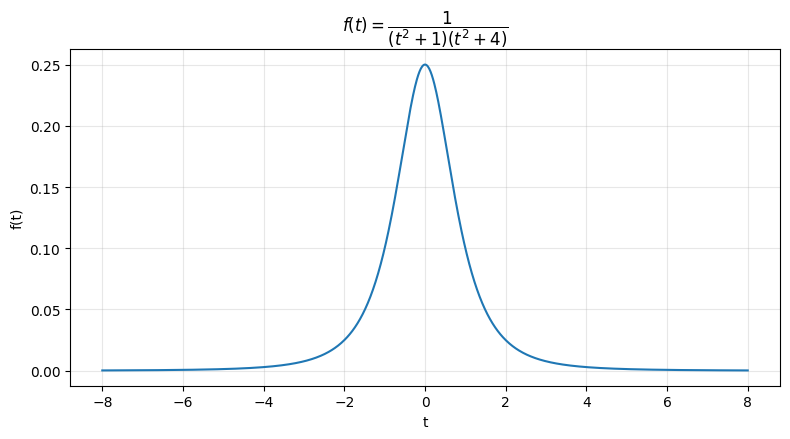

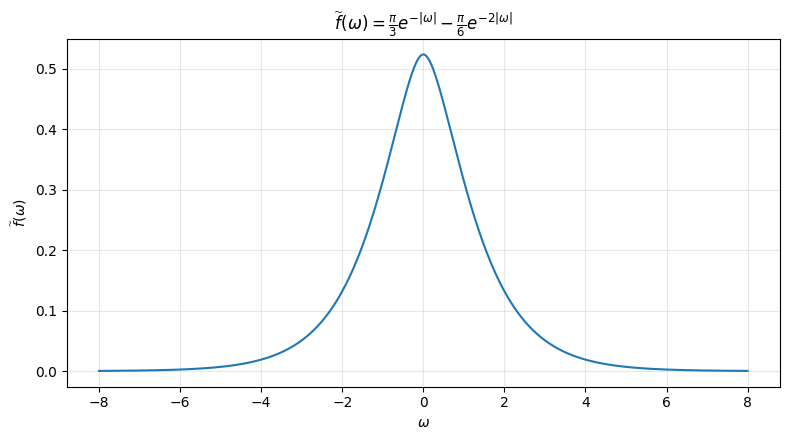

In [8]:
f_lam = sp.lambdify(t, f, 'numpy')
F_lam = sp.lambdify(omega, F_final, 'numpy')

tt = np.linspace(-8, 8, 1000)
ww = np.linspace(-8, 8, 1000)

plt.figure(figsize=(8, 4.5))
plt.plot(tt, f_lam(tt))
plt.title(r"$f(t)=\dfrac{1}{(t^2+1)(t^2+4)}$")
plt.xlabel("t")
plt.ylabel("f(t)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
plt.plot(ww, F_lam(ww))
plt.title(r"$\widetilde f(\omega)=\frac{\pi}{3}e^{-|\omega|}-\frac{\pi}{6}e^{-2|\omega|}$")
plt.xlabel(r"$\omega$")
plt.ylabel(r"$\widetilde f(\omega)$")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 7. Conclusión

La estrategia del ejemplo fue:

- reconocer que la función puede escribirse como un producto;
- aplicar el teorema de convolución para productos;
- resolver la integral resultante por tramos;
- usar paridad para extender el resultado a todo $\omega$;
- verificar el cálculo con SymPy.

En consecuencia,

$$
\boxed{
\mathcal F\!\left[\frac{1}{(t^2+1)(t^2+4)}\right](\omega)
=
\frac{\pi}{3}e^{-|\omega|}
-
\frac{\pi}{6}e^{-2|\omega|}
}.
$$
